# 02 — Cross-Sectional Momentum Research (Example)

**Research question**: Can cross-sectional momentum generate stable
out-of-sample risk-adjusted returns across liquid multi-asset ETFs after
transaction costs and volatility targeting?

**Universe**: SPY, QQQ, IWM, EFA, EEM, TLT, GLD, VNQ — US large/small
cap, developed/emerging ex-US equities, long treasuries, gold, real estate.

**Signal**: 12-month return excluding the most recent month (standard
momentum construction to avoid short-term reversal), ranked cross-sectionally
each month; long the top half.

**Hypothesis** (H1): after realistic transaction costs and out-of-sample
validation, the strategy delivers a positive risk-adjusted return (Sharpe > 0)
that is reasonably stable across sub-periods.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.backtesting.runner import run_backtest_from_config

config = ExperimentConfig.from_yaml("../configs/momentum_sp500.yaml")
data, report = DataLoader().load(config)
len(data), report.row_count


(36232, 36232)

## Run the backtest

In [2]:
result = run_backtest_from_config(data, config, data_quality_report=report)
print(result.summary())


Experiment : cross_sectional_momentum_etfs
Strategy   : cross_sectional_momentum
Symbols    : SPY, QQQ, IWM, EFA, EEM, TLT, GLD, VNQ
Period     : 2008-01-02 -> 2025-12-31
------------------------------------------------
Total return       :    163.60%
CAGR               :      5.54%
Volatility (ann.)  :      8.85%
Sharpe             :       0.43
Sortino            :       0.59
Calmar             :       0.35
Max drawdown       :    -15.76%
Hit rate (non-zero periods): 54.41%
Total costs (currency units): 6082.80
Number of fills    :       1514
------------------------------------------------
Beta               :       0.24
Alpha (ann.)       :      1.27%
Information ratio  :      -0.40


## Equity curve vs benchmark

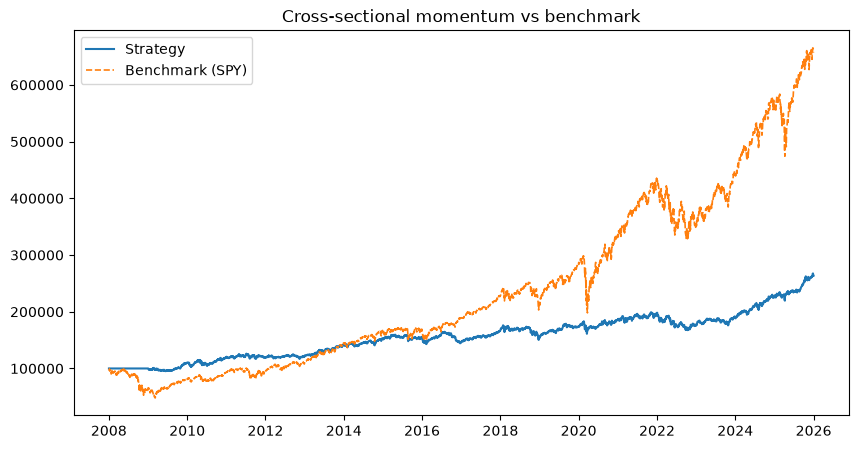

In [3]:
equity = result.equity_curve
benchmark_returns = result.benchmark_returns

if benchmark_returns is None:
    raise RuntimeError("No benchmark returns are available for this backtest.")

bench_equity = float(equity.iloc[0]) * (1 + benchmark_returns).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(equity.index, equity.to_numpy(dtype=float), label="Strategy", lw=1.5)
ax.plot(bench_equity.index, bench_equity.to_numpy(dtype=float), label=f"Benchmark ({config.benchmark_label})", lw=1.2, ls="--")
ax.set_title("Cross-sectional momentum vs benchmark")
ax.legend()
plt.show()


## Performance by year

In [4]:
from quantlab.reporting.tables import subperiod_table
table = subperiod_table(result)
table


,Period,Return,CAGR,Sharpe,Max Drawdown,Volatility,Turnover (x),Number of Trades
0,Full sample,1.635962,0.055411,0.427824,-0.157609,0.088476,69.768469,1514
1,2008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,2009,0.095022,0.095022,0.830386,-0.056402,0.090113,2.053810,77
3,2010,0.090933,0.090933,0.605746,-0.092496,0.123149,4.223507,59
4,2011,-0.002498,-0.002498,-0.182903,-0.074265,0.097250,6.897623,91
5,2012,0.018649,0.018799,0.009690,-0.064629,0.063098,3.839803,85
6,2013,0.168726,0.168726,1.785126,-0.043570,0.077859,6.727745,125
7,2014,0.067057,0.067057,0.605993,-0.056584,0.079287,3.134767,118
8,2015,0.018298,0.018298,0.017501,-0.072169,0.081181,4.989966,80
9,2016,-0.050989,-0.050989,-0.844310,-0.123632,0.081721,4.910285,78


## Out-of-sample validation (walk-forward)

Parameters are selected on a validation block and only then evaluated on an
untouched test block — the test period is never used to choose
`lookback_period`, `skip_period` or `top_fraction`. The notebook calls the same
configured-or-default grid helper as the CLI, so both interfaces evaluate
identical candidates.


In [5]:
from quantlab.validation import WalkForwardValidator, parameter_grid_for_config

train_window = config.validation.train_window or 500
validation_window = config.validation.validation_window or 126
test_window = config.validation.test_window or 126

validator = WalkForwardValidator(config)
wf = validator.run(
    data,
    parameter_grid=parameter_grid_for_config(config),
    train_window=train_window,
    validation_window=validation_window,
    test_window=test_window,
    expanding=config.validation.expanding,
)
print(f"{len(wf.folds)} walk-forward folds")
wf.summary_table()


26 walk-forward folds


,fold,param_lookback_period,param_skip_period,validation_score,test_return,test_sharpe
0,0,189,21,0.395150,0.002246,-0.148399
1,1,252,21,0.381388,0.086119,2.141740
2,2,252,21,1.509166,0.032850,0.577043
3,3,126,21,1.791084,0.036955,1.126486
4,4,189,21,1.263127,0.007165,-0.040030
5,5,189,21,1.362616,-0.046294,-1.043426
6,6,252,21,-0.186246,0.063801,1.217540
7,7,126,21,0.269069,-0.051130,-1.423099
8,8,126,0,0.798420,0.051993,1.344901
9,9,189,21,1.260655,0.078582,2.180407


In [6]:
oos_metrics = wf.oos_metrics(config.periods_per_year, config.risk_free_rate)
print(f"Out-of-sample Sharpe: {oos_metrics.get('sharpe_ratio', 0):.2f}")
print(f"Out-of-sample CAGR:   {oos_metrics.get('cagr', 0):.2%}")
print(f"Parameter stability (coefficient of variation): {wf.parameter_stability()}")


Out-of-sample Sharpe: 0.31
Out-of-sample CAGR:   4.56%
Parameter stability (coefficient of variation): {'lookback_period': 0.227497050075337, 'skip_period': 0.6666666666666667}


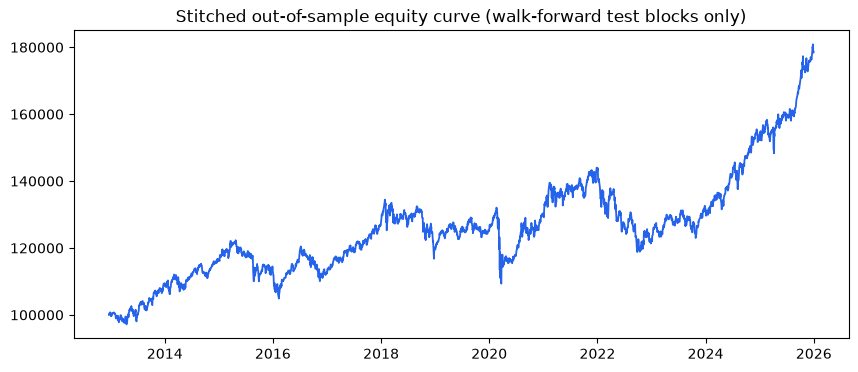

In [7]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wf.oos_equity.index, wf.oos_equity.to_numpy(dtype=float), color="#2563eb", lw=1.3)
ax.set_title("Stitched out-of-sample equity curve (walk-forward test blocks only)")
plt.show()


## Conclusion

The strategy's full-sample and walk-forward out-of-sample Sharpe ratios are
relatively close, which provides some reassurance against severe overfitting.
However, the observed risk-adjusted performance remains modest and does not
demonstrate a persistent ability to outperform the market. These results are
historical, depend on the stated assumptions and execution costs, and do not
guarantee future performance.
